# 11 - Setup shot

**Input:** `data/processed/strokes_all.csv`, `data/processed/player_sex.csv`, `data/raw/match.csv`
**What it does:** women's singles. Tests whether the winner engineers the point with one big setup shot. Compares the winner's penultimate (setup) shot to their own rally-wide baseline, reports the share of rallies that end on the loser's racket, and plots the displacement trajectory over the final shots.
**Output:** `output/setup_shot.png`, printed tables.

Analysis type: descriptive / mechanism test. Finding: the setup shot is about average for the winner (no engineered setup); ~63% of rallies end on the loser's error.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils

In [3]:
## CONFIG
PROC_DIR = utils.PROC_DIR
OUT_DIR = utils.OUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)
RESTRICT_TO_WOMENS = True
MIN_SHOTS = 4   ## need a few shots so 'penultimate' is meaningful

## Load, resolve names, restrict to women's

In [4]:
strokes = utils.load_strokes()
matches = utils.load_matches()
strokes = utils.map_player_names(strokes, matches)
if RESTRICT_TO_WOMENS:
    strokes = utils.restrict_to_womens(strokes, how="sex")
print("strokes:", len(strokes))

map_player_names: rows before merge = 52356, after = 52356
map_player_names: unique players resolved = 35
restrict_to_womens: rows before filter = 52356, after = 22503
strokes: 22503


## Identify each rally's shot sequence (uses utils.add_rally_sequence)\nAdds rally_len, seq, and from_end (0 = last shot, 1 = penultimate).

In [5]:
strokes = strokes.dropna(subset=["displacement", "hitter_won_rally"]).copy()
strokes = utils.add_rally_sequence(strokes, min_shots=MIN_SHOTS)

## the last shot can be hit by EITHER player. We use hitter_won_rally (reliable,
## built in nb 02 from getpoint_player) rather than assuming last hitter == winner.
last_shots = strokes[strokes["from_end"] == 0]
print("share of rallies that END on the loser's racket (their error):",
      round(1 - last_shots["hitter_won_rally"].mean(), 3))
print("(the rest end on the winner's putaway)")

share of rallies that END on the loser's racket (their error): 0.634
(the rest end on the winner's putaway)


## Penultimate ('setup') shot = from_end == 1\nSplit by who won; compare the winner's setup shot to the winner's own baseline.

In [6]:
pen = strokes[strokes["from_end"] == 1].copy()
pen_winner = pen[pen["hitter_won_rally"] == 1]
pen_loser = pen[pen["hitter_won_rally"] == 0]

winner_baseline = strokes[strokes["hitter_won_rally"] == 1]["displacement"].mean()
loser_baseline = strokes[strokes["hitter_won_rally"] == 0]["displacement"].mean()

print(f"winner's setup shot: mean {pen_winner['displacement'].mean():.1f}  median {pen_winner['displacement'].median():.1f}  n={len(pen_winner)}")
print(f"loser's setup shot:  mean {pen_loser['displacement'].mean():.1f}  median {pen_loser['displacement'].median():.1f}  n={len(pen_loser)}")
print(f"winner's overall baseline: {winner_baseline:.1f}")
print(f"loser's overall baseline:  {loser_baseline:.1f}")

lift = pen_winner["displacement"].mean() - winner_baseline
print(f"winner's setup shot vs own baseline: {lift:+.1f}")
if lift > 15:
    print("=> setup shot moves opponent MORE than usual (engineered kill).")
elif lift < -15:
    print("=> setup shot SMALLER than usual.")
else:
    print("=> setup shot about AVERAGE for them (no special setup); error comes")
    print("   out of an even exchange.")

winner's setup shot: mean 163.2  median 154.0  n=1176
loser's setup shot:  mean 146.7  median 142.9  n=685
winner's overall baseline: 159.4
loser's overall baseline:  159.4
winner's setup shot vs own baseline: +3.7
=> setup shot about AVERAGE for them (no special setup); error comes
   out of an even exchange.


## Displacement over the final shots (from_end 5..0), winners vs losers

In [7]:
endwin = strokes[strokes["from_end"] <= 5].groupby(["from_end", "hitter_won_rally"])["displacement"].mean().reset_index()
piv = endwin.pivot(index="from_end", columns="hitter_won_rally", values="displacement")
piv.columns = ["loser", "winner"]
piv = piv.sort_index(ascending=False)
print(piv.round(1))

          loser  winner
from_end               
5         159.1   155.4
4         154.1   161.6
3         153.1   160.0
2         160.9   172.3
1         146.7   163.2
0         213.3   204.2


## Figure

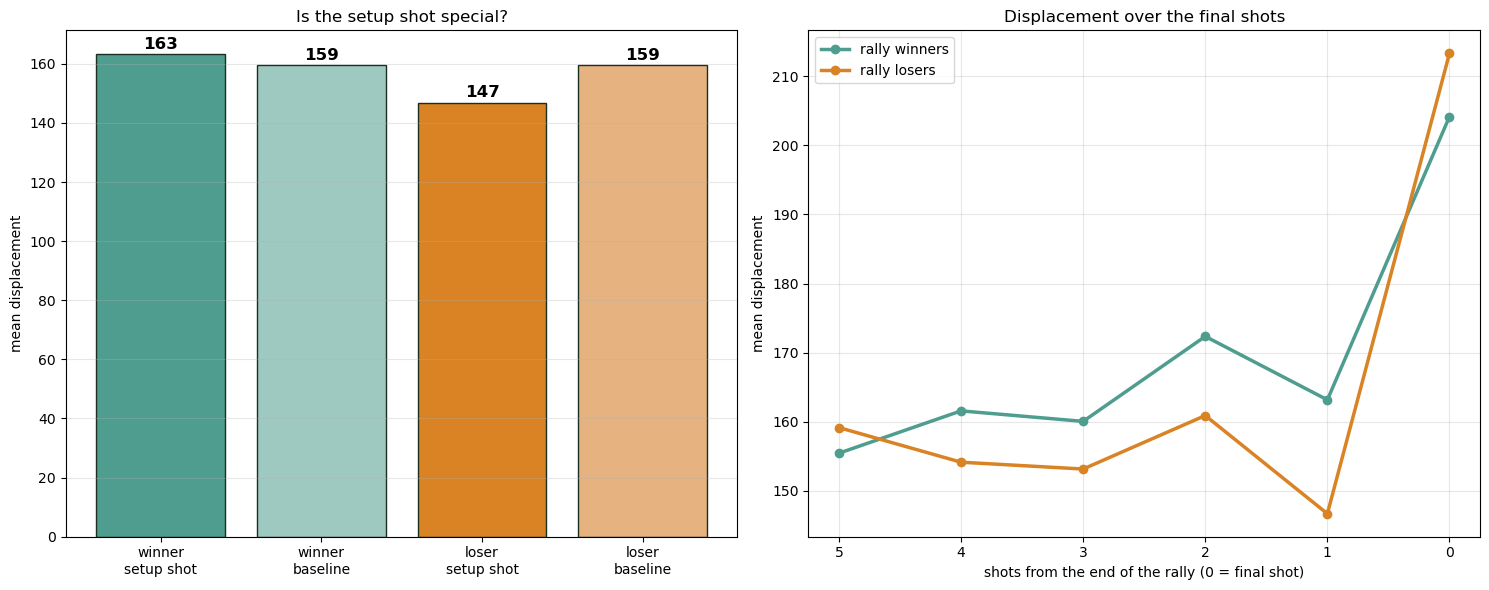

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
labels = ["winner\nsetup shot", "winner\nbaseline", "loser\nsetup shot", "loser\nbaseline"]
vals = [pen_winner["displacement"].mean(), winner_baseline,
        pen_loser["displacement"].mean(), loser_baseline]
colors = ["#4f9d8f", "#9ec9c0", "#D98324", "#e6b380"]
ax1.bar(labels, vals, color=colors, edgecolor="#1A2E22")
for i, v in enumerate(vals):
    ax1.text(i, v + 2, f"{v:.0f}", ha="center", fontsize=12, fontweight="bold")
ax1.set_ylabel("mean displacement"); ax1.set_title("Is the setup shot special?")
ax1.grid(True, axis="y", alpha=0.3)

ax2.plot(piv.index, piv["winner"], marker="o", linewidth=2.5, color="#4f9d8f", label="rally winners")
ax2.plot(piv.index, piv["loser"], marker="o", linewidth=2.5, color="#D98324", label="rally losers")
ax2.set_xlabel("shots from the end of the rally (0 = final shot)")
ax2.set_ylabel("mean displacement"); ax2.set_title("Displacement over the final shots")
ax2.invert_xaxis(); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "setup_shot.png"), dpi=150)
plt.show()